In [12]:
import math
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
df = pd.read_csv('preprocessing-1.csv')
df['crash_date'] = pd.to_datetime(df['crash_date'])

In [3]:
print(df.nunique())

crash_date              1165
city                       2
district                  12
zone                      41
crash_occurred_on          6
type_of_roadway            5
road_surface              11
weather_condition          9
lighting_condition         8
injury                     2
fatality                   2
hit_and_run                2
pedestrian_involved        2
train_involved             2
intersection               2
total_vehicles             9
vehicle_alignment          4
relation_to_roadway       11
manner_of_collision       22
primary_factor            12
secondary_factor          13
latitude               42308
longitude              42334
day_of_week                7
crash_month               12
dtype: int64


In [4]:
def countplot(df: pd.DataFrame, columns: list, grid_cols: int=2, palette: str='viridis'):
    """
    Creates a grid of count plots for the specified categorical columns.

    Args:
        df (pd.DataFrame): The DataFrame containing the data.
        columns (list): A list of column names to plot.
        grid_cols (int): The number of columns in the subplot grid.
    """
    num_plots = len(columns)
    grid_rows = math.ceil(num_plots/grid_cols)

    fig, axes = plt.subplots(
        nrows=grid_rows,
        ncols=grid_cols,
        figsize=(grid_cols*7, grid_rows*7)
    )
    
    axes = axes.flatten() # Axes is 2D, flattening it to 1D
    
    for i, col in enumerate(columns):
        ax = axes[i]
        sns.countplot(
            data=df,
            y=col,
            order=df[col].value_counts().index,
            ax=ax,
            palette=palette
        )

        ax.set_title(f'Distribution of {' '.join(col.split('_')).title()}', fontsize=12)
        ax.set_xlabel('Count')
        ax.set_ylabel('')

    # Turn all the axes that haven't been used
    for i in range(num_plots, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()

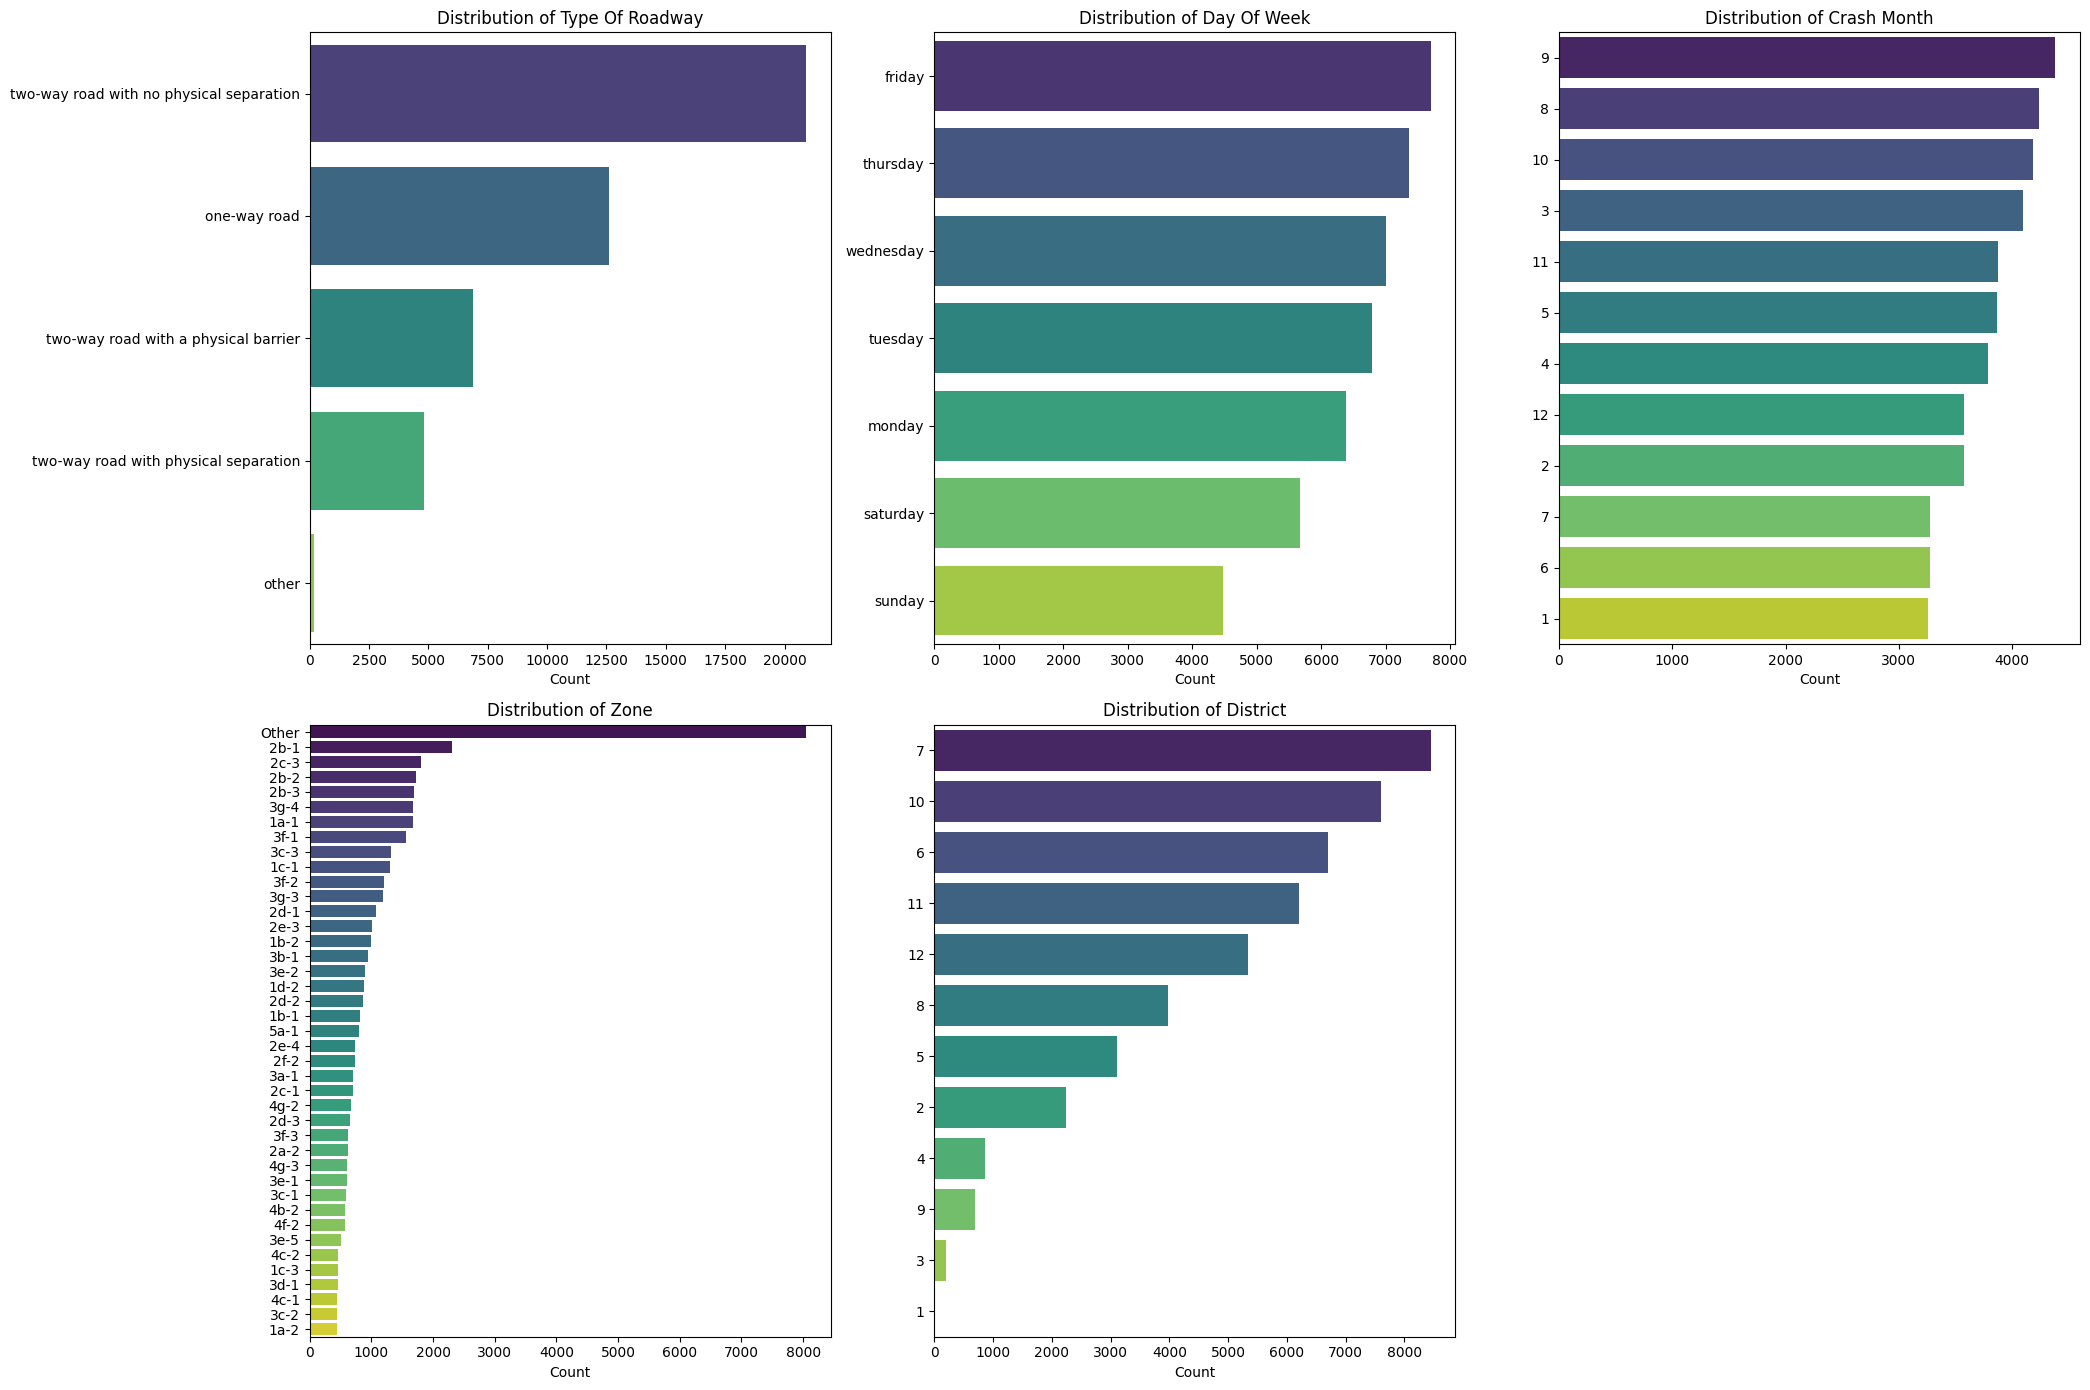

In [5]:
countplot_cols = ['type_of_roadway', 'day_of_week', 'crash_month', 'zone', 'district']
countplot(df=df, columns=countplot_cols, grid_cols=3)

In [13]:
df['crash_year'] = df['crash_date'].dt.year

In [25]:
import pandas as pd
import plotly.express as px

# Assuming 'df' is your DataFrame and 'crash_date' is a datetime object
# df['crash_date'] = pd.to_datetime(df['crash_date'])

# --- Data Preparation (same as before) ---
df['crash_year'] = df['crash_date'].dt.year
df['crash_month'] = df['crash_date'].dt.month

# Group by year and month to get crash counts
monthly_counts = df.groupby(['crash_year', 'crash_month']).size().reset_index(name='count')

# --- Plotting with Facets ---
fig = px.line(
    monthly_counts,
    x='crash_month',
    y='count',
    facet_col='crash_year',  # <-- This creates separate plots for each year
    facet_col_wrap=3,      # <-- Wrap subplots into rows of 3
    markers=True,
)

# --- Customize Layout ---
# Update titles and axis labels
fig.update_layout(
    title_text='Monthly Crash Counts by Year',
    yaxis_title='Number of Crashes'
)

# Update x-axis to show month names on all subplots
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig.update_xaxes(
    title_text='Month',
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=month_names
)

# Make subplot titles more concise (e.g., just the year)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

# # Save the interactive plot to an HTML file
# fig.write_html("faceted_crashes_by_year.html")

# print("Faceted plot saved as 'faceted_crashes_by_year.html'. Open this file in your browser.")

In [22]:
df['crash_year'].value_counts()

crash_year
2024    15285
2023    14703
2025    10090
2022     5298
2021        9
Name: count, dtype: int64

In [16]:
import pandas as pd
import plotly.express as px

# Assuming 'df' is your DataFrame and 'crash_date' is a datetime object
# df['crash_date'] = pd.to_datetime(df['crash_date'])

# --- Data Preparation ---
# Ensure year and month columns exist
df['crash_year'] = df['crash_date'].dt.year
df['crash_month'] = df['crash_date'].dt.month

# Group by year and month to get crash counts
monthly_counts = df.groupby(['crash_year', 'crash_month']).size().reset_index(name='count')

# Convert year to a categorical type for better plotting with discrete colors
monthly_counts['crash_year'] = monthly_counts['crash_year'].astype(str)

# --- Plotting with Plotly Express ---
fig = px.line(
    monthly_counts,
    x='crash_month',
    y='count',
    color='crash_year',  # Creates a separate line for each year
    markers=True,        # Adds markers to each data point
    labels={
        "crash_month": "Month",
        "count": "Number of Crashes",
        "crash_year": "Year"
    },
    title="Interactive: Crashes per Month by Year"
)

# --- Customize Layout ---
# Update x-axis to show month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fig.update_xaxes(
    tickmode='array',
    tickvals=list(range(1, 13)),
    ticktext=month_names
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="Number of Crashes",
    legend_title="Year"
)
fig.show()
# Save the interactive plot to an HTML file
# fig.write_html("interactive_crashes_by_month.html")

# print("Interactive plot saved as 'interactive_crashes_by_month.html'. Open this file in your browser.")